# 00 — Roadmap and Mathematical Primer
## Advanced Model Predictive Control & Learning MPC

This notebook builds the **mathematical vocabulary and mental models** used throughout the repository. It is intentionally more than a list of formulas: the goal is to understand how dynamics, optimization, constraints, stability, invariant sets, dynamic programming, and learning fit together.

By the end, you should be able to explain every link in the following chain:

$$
\boxed{\text{dynamics}}
\;\longrightarrow\;
\boxed{\text{prediction}}
\;\longrightarrow\;
\boxed{\text{constrained optimal control}}
\;\longrightarrow\;
\boxed{\text{receding horizon MPC}}
$$

$$
\boxed{\text{terminal set + terminal value}}
\;\longrightarrow\;
\boxed{\text{recursive feasibility + stability}}
\;\longrightarrow\;
\boxed{\text{learn those ingredients from data (LMPC)}}.
$$

> **Big idea.** Classical feedback tells us how to react to the current state. MPC adds two ingredients that become essential for complex systems: **prediction** and **explicit constraint handling**.

### Learning objectives

After working through this notebook, you should be able to:

- distinguish nonlinear, LTI, LTV, and affine discrete-time models;
- derive stacked prediction matrices $\mathcal S_x,\mathcal S_u$;
- recognize when a finite-horizon linear-quadratic problem becomes a convex QP;
- distinguish feasibility, recursive feasibility, invariance, and stability;
- derive the discrete LQR gain and the associated Lyapunov decrease identity;
- explain the role of terminal sets and terminal costs in stabilizing MPC;
- state Bellman's recursion and connect value functions to MPC;
- explain how Learning MPC replaces hand-designed terminal ingredients with successful closed-loop data;
- understand why Frenet coordinates are convenient for path/racing problems.

This notebook uses `$...$` and `$$...$$` math delimiters so equations render correctly in **VS Code, Jupyter, and GitHub**.


## 0. Repository roadmap

The notebooks are organized as a progression rather than as independent demos.

| Notebook | Main question | Core mathematics |
|---|---|---|
| **00** | What language do all later notebooks share? | state space, QP, Lyapunov, sets, Bellman |
| **01** | How do we formulate finite-horizon constrained control? | convex optimization, CFTOC, KKT intuition |
| **02** | Which states can reach / remain in a safe set? | polytopes, predecessor operators, invariance |
| **03** | Why can MPC be recursively feasible and stable? | shifted sequence, terminal controller, Lyapunov decrease |
| **04** | How do logical choices enter optimal control? | collision avoidance, mixed logical/continuous decisions |
| **05** | How can repeated successful trajectories improve MPC? | sampled/convex safe sets, learned terminal value |
| **06** | How do we formulate minimum-time racing? | Frenet coordinates, spatial dynamics, CFTOC |
| **07** | How can data provide a local prediction model? | local affine/LTV identification for control |
| **08** | How are optimal control, DP and RL related? | Bellman equations, value/policy iteration |
| **09** | Can we justify and extend the full pipeline? | synthesis, design choices, limitations |

### Suggested way to study

For every notebook, always identify four layers:

1. **Model:** what are the state $x$, input $u$, and dynamics $f$?
2. **Optimization:** what are the decision variables, objective, and constraints?
3. **Guarantees:** what gives feasibility, safety, or stability?
4. **Limitations:** which assumptions would fail on a real platform?

The same four questions also give a good structure for explaining or reviewing any controller design.


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
from scipy.spatial import ConvexHull

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from advanced_mpc_lmpc.linear import prediction_matrices, dlqr, rollout
from advanced_mpc_lmpc.mpc import LinearMPC, simulate_receding_horizon
from advanced_mpc_lmpc.polytopes import HPolytope, maximal_invariant

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.figsize": (8, 4.6),
    "axes.grid": True,
    "font.size": 11,
})

print("Project root:", ROOT.name)


Project root: advanced_mpc_lmpc_lab


## Table of Contents

- **[Part I — The language of dynamical systems](#part-1)** — I.1 State, input, dynamics, output · I.2 Notation and mathematical conventions
- **[Part II — Prediction: turning dynamics into algebra](#part-2)** — II.1 Multi-step prediction
- **[Part III — Optimization and finite-horizon optimal control](#part-3)** — III.1 Anatomy of a constrained optimization problem · III.2 From a quadratic control objective to a QP · III.3 Constrained finite-time optimal control (CFTOC)
- **[Part IV — Receding horizon control](#part-4)** — IV.1 MPC is an optimization-generated feedback law · IV.2 Four notions that must not be conflated
- **[Part V — Stability and LQR](#part-5)** — V.1 Continuous-time and discrete-time stability tests are different · V.2 Infinite-horizon LQR and the DARE
- **[Part VI — Reachability and invariant sets](#part-6)** — VI.1 Predecessors: “from where can I enter this set in one step?” · VI.2 Positive invariance versus control invariance · VI.3 A terminal invariant set for constrained LQR
- **[Part VII — Why terminal ingredients matter in MPC](#part-7)** — VII.1 The standard terminal-set stability mechanism · VII.2 Recursive feasibility: the shifted-sequence argument · VII.3 Stability: the optimal MPC value as a Lyapunov function
- **[Part VIII — Dynamic programming and value functions](#part-8)** — VIII.1 Bellman's principle of optimality
- **[Part IX — From designed terminal ingredients to Learning MPC](#part-9)** — IX.1 Why learn a terminal set or terminal value? · IX.2 Sampled safe set · IX.3 Convex safe set and barycentric coordinates · IX.4 Learning a terminal value from stored cost-to-go
- **[Part X — Preview: autonomous racing in Frenet coordinates](#part-10)** — X.1 Why change coordinates?
- **[Part XI — Common conceptual pitfalls](#part-11)** — XI.1 Things worth catching before an implementation review
- **[Part XII — Check your understanding](#part-12)**
- **[Part XIII — Exercises](#part-13)**
- **[Part XIV — Notation cheat sheet](#part-14)**
- **[Part XV — Scope and references](#part-15)**


---
<a id="part-1"></a>
# Part I — The language of dynamical systems

## I.1 State, input, dynamics, output

A deterministic discrete-time system is written

$$
x_{k+1}=f_k(x_k,u_k),
$$

with

$$
x_k\in\mathbb R^n,\qquad u_k\in\mathbb R^m.
$$

The **state** is a sufficient internal description: once $x_k$ and future inputs are known, the model can predict future states. An output equation may be added,

$$
y_k=h_k(x_k,u_k),
$$

but MPC is most naturally formulated in state space.

### Models we will repeatedly use

**LTI (linear time invariant)**

$$
x_{k+1}=Ax_k+Bu_k.
$$

**Affine**

$$
x_{k+1}=Ax_k+Bu_k+c.
$$

**LTV (linear time varying)**

$$
x_{k+1}=A_kx_k+B_ku_k+c_k.
$$

**Nonlinear**

$$
x_{k+1}=f(x_k,u_k).
$$

The later racing notebooks deliberately move between these descriptions: the simulated vehicle may be nonlinear, while the optimizer can use a locally identified or linearized prediction model.

> **Important:** the *plant/test model* and the *prediction model* do not have to coincide. MPC optimizes with a model; the real system evolves according to physics. Model mismatch is therefore a central practical issue.


### I.1.1 Running example: a sampled double integrator

Let position be $p$ and velocity be $v$. With constant acceleration $a$ over one sample of duration $T_s$,

$$
\begin{aligned}
p_{k+1} &= p_k + T_s v_k + \frac{1}{2}T_s^2 a_k,\\
v_{k+1} &= v_k + T_s a_k.
\end{aligned}
$$

Therefore

$$
x_k=\begin{bmatrix}p_k\\v_k\end{bmatrix},\qquad
u_k=a_k,
$$

and

$$
A=\begin{bmatrix}1&T_s\\0&1\end{bmatrix},\qquad
B=\begin{bmatrix}T_s^2/2\\T_s\end{bmatrix}.
$$

This tiny system is useful because it already contains the main MPC difficulties: the input affects velocity immediately, position only indirectly, and physical limits naturally create constraints on both states and inputs.


A =
 [[1. 1.]
 [0. 1.]]
B =
 [[0.5]
 [1. ]]
trajectory [position, velocity] =
 [[-5.   0. ]
 [-4.5  1. ]
 [-3.   2. ]
 [-1.   2. ]
 [ 0.5  1. ]
 [ 1.   0. ]]


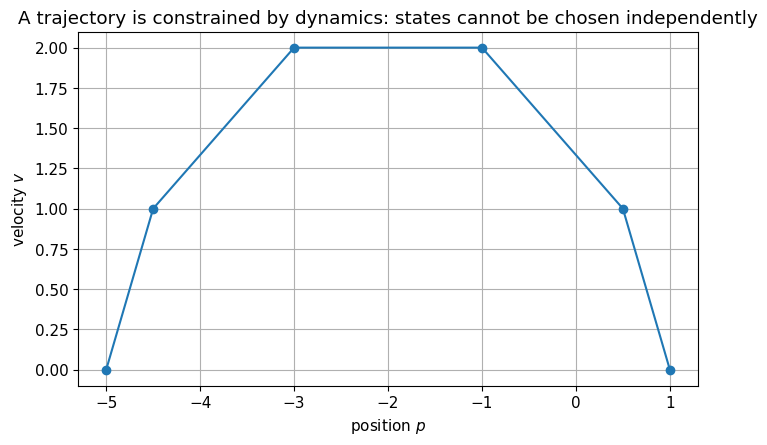

In [2]:
Ts = 1.0
A = np.array([[1.0, Ts],
              [0.0, 1.0]])
B = np.array([[0.5 * Ts**2],
              [Ts]])

x0 = np.array([-5.0, 0.0])
U_demo = np.array([[1.0], [1.0], [0.0], [-1.0], [-1.0]])
X_demo = rollout(A, B, x0, U_demo)

print("A =\n", A)
print("B =\n", B)
print("trajectory [position, velocity] =\n", X_demo)

fig, ax = plt.subplots()
ax.plot(X_demo[:, 0], X_demo[:, 1], "o-")
ax.set_xlabel("position $p$")
ax.set_ylabel("velocity $v$")
ax.set_title("A trajectory is constrained by dynamics: states cannot be chosen independently")
plt.show()


## I.2 Notation and mathematical conventions

The following conventions will be used consistently.

### Vectors and matrices

- $x^\top y$: Euclidean inner product.
- $\|x\|_2=\sqrt{x^\top x}$: Euclidean norm.
- $P=P^\top\succ0$: symmetric positive definite matrix.
- $P\succeq0$: symmetric positive semidefinite matrix.
- $\lambda_i(A)$: eigenvalues of $A$.
- $\rho(A)=\max_i|\lambda_i(A)|$: spectral radius.

A quadratic form

$$
V(x)=x^\top Px
$$

is strictly positive for all $x\neq0$ exactly when $P\succ0$.

### Set notation

A polyhedral state constraint is commonly written

$$
\mathcal X=\{x\in\mathbb R^n:H_xx\le h_x\},
$$

and an input set as

$$
\mathcal U=\{u\in\mathbb R^m:H_uu\le h_u\}.
$$

Inequalities between vectors are componentwise.

### Feedback sign convention

Throughout this repository, LQR feedback is written

$$
\boxed{u=-Kx}.
$$

Hence

$$
\boxed{A_{\mathrm{cl}}=A-BK}.
$$

If another text defines $u=Fx$, then $F=-K$ and the same closed loop may appear as $A+BF$. Always check the convention before copying a stability formula.


---
<a id="part-2"></a>
# Part II — Prediction: turning dynamics into algebra

## II.1 Multi-step prediction

MPC needs to predict how an input sequence affects future states. For the LTI model

$$
x_{k+1}=Ax_k+Bu_k,
$$

the first steps are

$$
\begin{aligned}
x_1 &= Ax_0+Bu_0,\\
x_2 &= A^2x_0+ABu_0+Bu_1,\\
x_3 &= A^3x_0+A^2Bu_0+ABu_1+Bu_2.
\end{aligned}
$$

Stack

$$
X=\begin{bmatrix}x_1\\x_2\\\vdots\\x_N\end{bmatrix},\qquad
U=\begin{bmatrix}u_0\\u_1\\\vdots\\u_{N-1}\end{bmatrix}.
$$

Then

$$
\boxed{X=\mathcal S_xx_0+\mathcal S_uU},
$$

with

$$
\mathcal S_x=
\begin{bmatrix}
A\\A^2\\\vdots\\A^N
\end{bmatrix},
$$

and the lower block-Toeplitz matrix

$$
\mathcal S_u=
\begin{bmatrix}
B&0&\cdots&0\\
AB&B&\cdots&0\\
\vdots&\vdots&\ddots&\vdots\\
A^{N-1}B&A^{N-2}B&\cdots&B
\end{bmatrix}.
$$

This single identity is the backbone of **condensed linear MPC**.


In [3]:
N = 4
Sx, Su = prediction_matrices(A, B, N)
print("Sx shape:", Sx.shape)
print("Su shape:", Su.shape)
print("\nSx =\n", Sx)
print("\nSu =\n", Su)

# Numerical verification against direct simulation
U = np.array([[0.8], [0.2], [-0.4], [-0.5]])
X_rollout = rollout(A, B, x0, U)[1:].reshape(-1)
X_condensed = Sx @ x0 + Su @ U.reshape(-1)

print("\nmax prediction error =", np.max(np.abs(X_rollout - X_condensed)))
assert np.allclose(X_rollout, X_condensed)


Sx shape: (8, 2)
Su shape: (8, 4)

Sx =
 [[1. 1.]
 [0. 1.]
 [1. 2.]
 [0. 1.]
 [1. 3.]
 [0. 1.]
 [1. 4.]
 [0. 1.]]

Su =
 [[0.5 0.  0.  0. ]
 [1.  0.  0.  0. ]
 [1.5 0.5 0.  0. ]
 [1.  1.  0.  0. ]
 [2.5 1.5 0.5 0. ]
 [1.  1.  1.  0. ]
 [3.5 2.5 1.5 0.5]
 [1.  1.  1.  1. ]]

max prediction error = 1.1102230246251565e-16


### Checkpoint — what is really being optimized?

In the **condensed** formulation, the future states are eliminated using

$$
X=\mathcal S_xx_0+\mathcal S_uU.
$$

The optimization variable is then only $U$.

In the **sparse/uncondensed** formulation, both $X$ and $U$ remain optimization variables, and the dynamics are imposed as equality constraints.

Neither formulation changes the control problem; they only change its numerical representation. Sparse formulations often scale better for long horizons and structured solvers, whereas condensed QPs are convenient for small/medium linear MPC problems.


---
<a id="part-3"></a>
# Part III — Optimization and finite-horizon optimal control

## III.1 Anatomy of a constrained optimization problem

A generic optimization problem is

$$
\begin{aligned}
\min_z\quad & f(z)\\
\text{s.t.}\quad & g_i(z)\le0,\quad i=1,\ldots,m,\\
& h_j(z)=0,\quad j=1,\ldots,p.
\end{aligned}
$$

Here $z$ is the **decision variable**. In optimal control, $z$ may contain a complete input trajectory, a state trajectory, logical variables, or combinations of them.

### Convexity matters

If

- $f$ is convex,
- each inequality function $g_i$ is convex,
- each equality constraint $h_j$ is affine,

then the problem is convex. Any local optimum is global.

A quadratic program (QP) has the standard form

$$
\begin{aligned}
\min_z\quad & \frac12 z^\top Hz+q^\top z\\
\text{s.t.}\quad & Gz\le b,\\
& Ez=d,
\end{aligned}
$$

and is convex when $H\succeq0$.

> Convexity is not just mathematical elegance: it changes what we can reliably solve online.


## III.2 From a quadratic control objective to a QP

Consider the horizon-$N$ linear-quadratic cost

$$
J_N=
\sum_{k=0}^{N-1}
\left(x_k^\top Qx_k+u_k^\top Ru_k\right)
+x_N^\top Px_N,
$$

where

$$
Q\succeq0,\qquad R\succ0,\qquad P\succeq0.
$$

Ignoring the constant term involving $x_0$, define

$$
\bar Q=\mathrm{blkdiag}(Q,\ldots,Q,P),\qquad
\bar R=I_N\otimes R.
$$

Since $X=\mathcal S_xx_0+\mathcal S_uU$,

$$
J_N(U;x_0)
=
(\mathcal S_xx_0+\mathcal S_uU)^\top
\bar Q
(\mathcal S_xx_0+\mathcal S_uU)
+U^\top\bar RU.
$$

Collecting terms gives

$$
J_N(U;x_0)=\frac12U^\top HU+f(x_0)^\top U+c(x_0),
$$

with

$$
\boxed{H=2(\mathcal S_u^\top\bar Q\mathcal S_u+\bar R)},
$$

$$
\boxed{f(x_0)=2\mathcal S_u^\top\bar Q\mathcal S_xx_0}.
$$

Because $R\succ0$, typically $H\succ0$, so the unconstrained minimizer is unique.


In [4]:
Q = np.diag([1.0, 0.2])
R = np.array([[0.1]])
P = Q.copy()
N = 6
Sx, Su = prediction_matrices(A, B, N)

Qbar = block_diag(*([Q] * (N - 1) + [P]))
Rbar = np.kron(np.eye(N), R)
H = 2 * (Su.T @ Qbar @ Su + Rbar)
f = 2 * Su.T @ Qbar @ Sx @ x0

print("eigenvalues(H) =", np.linalg.eigvalsh(H))
print("H is positive definite:", np.all(np.linalg.eigvalsh(H) > 1e-10))

# Unconstrained minimizer of 1/2 U'HU + f'U
U_star = -np.linalg.solve(H, f)
X_star = (Sx @ x0 + Su @ U_star).reshape(N, 2)
print("first optimal unconstrained input =", U_star[0])


eigenvalues(H) = [  0.3137   0.3697   0.5483   1.3056   7.9579 289.6046]
H is positive definite: True
first optimal unconstrained input = 4.199541601862761


### III.2.1 How constraints become linear inequalities in the condensed QP

Suppose each predicted state must satisfy

$$
H_xx_k\le h_x.
$$

After stacking,

$$
\bar H_xX\le \bar h_x.
$$

Substitute $X=\mathcal S_xx_0+\mathcal S_uU$:

$$
\boxed{
\bar H_x\mathcal S_uU
\le
\bar h_x-\bar H_x\mathcal S_xx_0
}.
$$

Input constraints are already linear in $U$:

$$
\bar H_uU\le\bar h_u.
$$

This exposes one of the most useful facts in linear MPC:

> **Linear dynamics + quadratic objective + polyhedral constraints $\Rightarrow$ convex QP.**

### Hard versus soft constraints

A hard constraint such as

$$
H_xx_k\le h_x
$$

must always hold. If temporary violation is physically tolerable, introduce a slack $\epsilon_k\ge0$:

$$
H_xx_k\le h_x+\epsilon_k,
$$

and penalize it, e.g.

$$
J\leftarrow J+\rho\sum_k\|\epsilon_k\|_1.
$$

Softening can protect against infeasibility, but it does **not** magically make a truly safety-critical constraint safe to violate. The modeling decision must reflect physics.


## III.3 Constrained finite-time optimal control (CFTOC)

For a general discrete-time system,

$$
x_{k+1}=f(x_k,u_k),
$$

a finite-horizon optimal control problem can be written

$$
\begin{aligned}
V_N^*(x_0)=
\min_{u_0,\ldots,u_{N-1}}\quad &
V_f(x_N)+\sum_{k=0}^{N-1}\ell(x_k,u_k)\\
\text{s.t.}\quad & x_{k+1}=f(x_k,u_k),\\
&x_k\in\mathcal X,\\
&u_k\in\mathcal U,\\
&x_N\in\mathcal X_f,\\
&x_0=x(0).
\end{aligned}
$$

Interpretation:

- $\ell(x,u)$ is the **stage cost**: what is expensive now?
- $V_f(x_N)$ is the **terminal cost**: what is the estimated price of the future beyond the prediction horizon?
- $\mathcal X_f$ is the **terminal set**: where must the prediction end so that the future can still be handled safely/stably?

The optimal solution is an entire open-loop sequence

$$
U^*(x_0)=\{u_0^*,u_1^*,\ldots,u_{N-1}^*\}.
$$

CFTOC by itself is an **open-loop planning problem**. MPC converts it into feedback by resolving it repeatedly.


---
<a id="part-4"></a>
# Part IV — Receding horizon control

## IV.1 MPC is an optimization-generated feedback law

At time $t$:

1. measure/estimate the current state $x(t)$;
2. solve the horizon-$N$ optimal control problem;
3. obtain $u_{0|t}^*,\ldots,u_{N-1|t}^*$;
4. apply only

$$
\boxed{u(t)=u_{0|t}^*};
$$

5. discard the unused tail, move to $t+1$, and solve again.

This is the **receding horizon principle**.

The resulting feedback law is implicitly defined by optimization:

$$
\kappa_N(x)=u_0^*(x).
$$

The optimizer is therefore not an offline trajectory generator; it is part of the controller.

### Why re-optimize?

Because the next measured state is rarely exactly the predicted state. Re-optimization incorporates disturbances, estimation errors, model mismatch, and changing references/constraints.


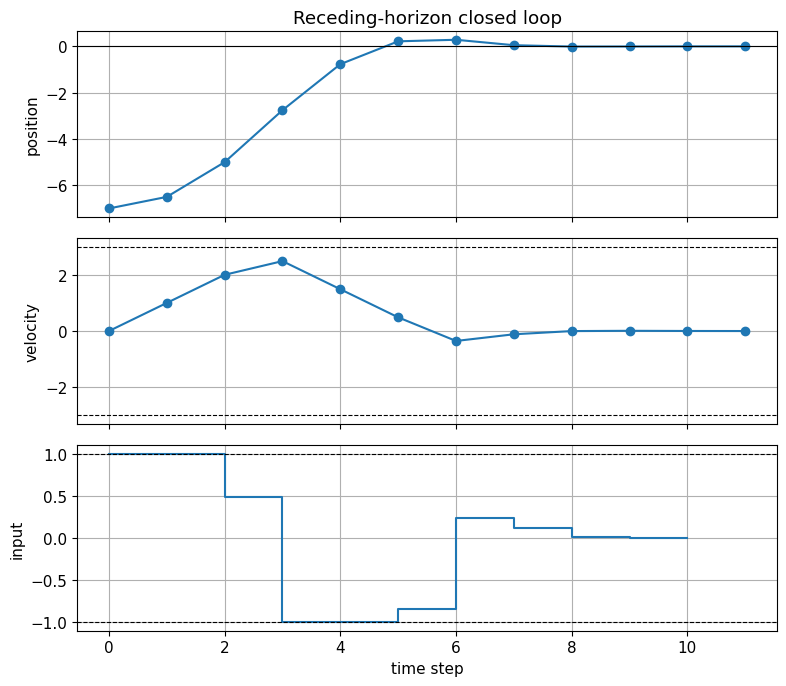

number of applied MPC moves: 11
final state: [ 0.0003 -0.0001]


In [5]:
# A compact receding-horizon demonstration.
# We deliberately keep it simple here; Notebook 03 develops the theory.

Q_mpc = np.diag([2.0, 0.4])
R_mpc = np.array([[0.2]])
N_mpc = 8

mpc = LinearMPC(
    A, B, Q_mpc, R_mpc, N=N_mpc,
    x_lower=np.array([-10.0, -3.0]),
    x_upper=np.array([ 10.0,  3.0]),
    u_lower=np.array([-1.0]),
    u_upper=np.array([ 1.0]),
)

x_init = np.array([-7.0, 0.0])
xs, us, costs = simulate_receding_horizon(mpc, x_init, steps=25)

fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True)
axes[0].plot(xs[:, 0], "o-")
axes[0].axhline(0, color="k", linewidth=0.8)
axes[0].set_ylabel("position")
axes[0].set_title("Receding-horizon closed loop")

axes[1].plot(xs[:, 1], "o-")
axes[1].set_ylabel("velocity")
axes[1].axhline(3, color="k", linestyle="--", linewidth=0.8)
axes[1].axhline(-3, color="k", linestyle="--", linewidth=0.8)

axes[2].step(np.arange(len(us)), us[:, 0], where="post")
axes[2].axhline(1, color="k", linestyle="--", linewidth=0.8)
axes[2].axhline(-1, color="k", linestyle="--", linewidth=0.8)
axes[2].set_ylabel("input")
axes[2].set_xlabel("time step")
plt.tight_layout()
plt.show()

print("number of applied MPC moves:", len(us))
print("final state:", xs[-1])


## IV.2 Four notions that must not be conflated

### IV.2.1 Feasibility

For a given state $x$, the finite-horizon problem is **feasible** if at least one admissible input sequence exists.

Define the $N$-step feasible set

$$
\mathcal X_N=\{x:\exists U\text{ satisfying all horizon constraints}\}.
$$

### IV.2.2 Recursive feasibility

An MPC law is recursively feasible if

$$
x(t)\in\mathcal X_N
\quad\Longrightarrow\quad
x(t+1)\in\mathcal X_N
$$

under the applied MPC input.

A controller can be feasible **now** but fail to remain feasible later. Recursive feasibility is the stronger closed-loop property.

### IV.2.3 Constraint satisfaction

If the optimization model is exact and the applied input is the first component of a feasible sequence, current-step hard constraints are satisfied. Under uncertainty, this conclusion needs robust/tube/chance-constraint arguments; nominal MPC alone is not a robust guarantee.

### IV.2.4 Stability

Feasibility only says that a legal trajectory exists. Stability says something about asymptotic behavior of the closed loop. A feasible MPC controller need not automatically stabilize the desired equilibrium.

> **A common pitfall:** “The optimizer solved successfully” is not a stability proof.


---
<a id="part-5"></a>
# Part V — Stability and LQR

## V.1 Continuous-time and discrete-time stability tests are different

For the continuous-time LTI system

$$
\dot x=Ax,
$$

asymptotic stability requires $A$ to be **Hurwitz**:

$$
\Re\lambda_i(A)<0.
$$

For the discrete-time LTI system

$$
x_{k+1}=Ax_k,
$$

asymptotic stability requires $A$ to be **Schur**:

$$
\boxed{\rho(A)<1}.
$$

### Discrete-time Lyapunov condition

Let

$$
V(x)=x^\top Px,\qquad P\succ0.
$$

Then

$$
\Delta V
=V(x_{k+1})-V(x_k)
=x_k^\top(A^\top PA-P)x_k.
$$

If there exists $P\succ0$ such that

$$
A^\top PA-P\prec0,
$$

the origin is asymptotically stable.

For an exponentially stable discrete-time LTI system, one can obtain

$$
\|x_k\|\le c\alpha^k\|x_0\|,
\qquad c>0,\quad 0<\alpha<1.
$$


## V.2 Infinite-horizon LQR and the DARE

Consider

$$
x_{k+1}=Ax_k+Bu_k
$$

and

$$
J_\infty=\sum_{k=0}^{\infty}
\left(x_k^\top Qx_k+u_k^\top Ru_k\right),
$$

with $Q\succeq0$ and $R\succ0$.

Under the usual stabilizability/detectability assumptions, the optimal stationary feedback is

$$
\boxed{u=-Kx},
$$

where

$$
K=(R+B^\top PB)^{-1}B^\top PA
$$

and $P$ solves the discrete algebraic Riccati equation (DARE)

$$
\boxed{
P=A^\top PA
-A^\top PB(R+B^\top PB)^{-1}B^\top PA
+Q.
}
$$

The closed-loop matrix is

$$
A_{\mathrm{cl}}=A-BK.
$$

A fundamental identity is

$$
\boxed{
A_{\mathrm{cl}}^\top P A_{\mathrm{cl}}-P
=-(Q+K^\top RK).
}
$$

Therefore, with $V(x)=x^\top Px$,

$$
V(x^+)-V(x)=-\ell(x,-Kx)<0
$$

away from the origin. This identity is precisely why the LQR value function is such a natural terminal cost for linear-quadratic MPC.


K = [[0.8399 1.3494]]
P =
 [[1.6066 0.3873]
 [0.3873 0.5286]]
closed-loop eigenvalues = [0.1153+0.2393j 0.1153-0.2393j]
spectral radius = 0.265602403550188
DARE/Lyapunov identity residual norm = 2.2764225665202706e-15


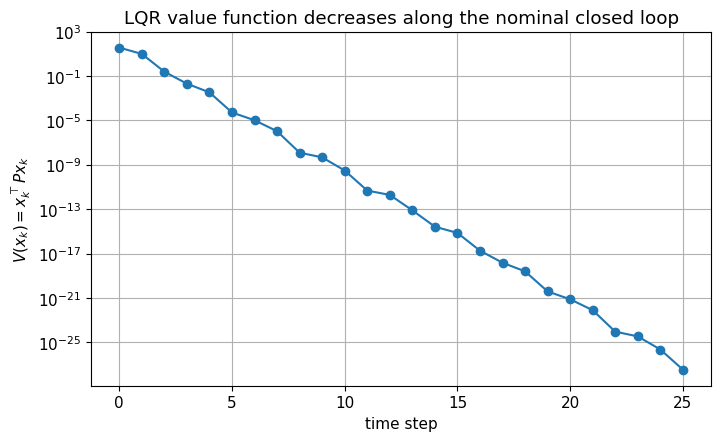

In [6]:
K, P_lqr, eig_cl = dlqr(A, B, Q, R)
Acl = A - B @ K
residual = Acl.T @ P_lqr @ Acl - P_lqr + Q + K.T @ R @ K

print("K =", K)
print("P =\n", P_lqr)
print("closed-loop eigenvalues =", eig_cl)
print("spectral radius =", np.max(np.abs(eig_cl)))
print("DARE/Lyapunov identity residual norm =", np.linalg.norm(residual))

# Show monotonic decrease of V along the LQR closed loop.
x = np.array([-5.0, 1.5])
Vs = []
Xs = [x.copy()]
for k in range(25):
    Vs.append(x @ P_lqr @ x)
    u = -K @ x
    x = A @ x + B @ u
    Xs.append(x.copy())
Vs.append(x @ P_lqr @ x)

fig, ax = plt.subplots()
ax.semilogy(Vs, "o-")
ax.set_xlabel("time step")
ax.set_ylabel(r"$V(x_k)=x_k^\top P x_k$")
ax.set_title("LQR value function decreases along the nominal closed loop")
plt.show()


---
<a id="part-6"></a>
# Part VI — Reachability and invariant sets

## VI.1 Predecessors: “from where can I enter this set in one step?”

For

$$
x^+=Ax+Bu,
$$

and a target set $\mathcal S$, define the one-step predecessor

$$
\boxed{
\mathrm{Pre}(\mathcal S)=
\{x:\exists u\in\mathcal U\text{ such that }Ax+Bu\in\mathcal S\}.
}
$$

Repeated predecessor operations answer finite-horizon reachability questions:

$$
\mathrm{Pre}^2(\mathcal S),\quad
\mathrm{Pre}^3(\mathcal S),\ldots
$$

This construction appears naturally when asking:

> “From which initial states can I reach a terminal/safe set within $N$ steps without violating constraints?”

That is closely related to an MPC feasible set.


## VI.2 Positive invariance versus control invariance

These definitions look similar but their quantifiers are different.

### Positively invariant set

For autonomous dynamics $x^+=F(x)$,

$$
\boxed{x\in\mathcal O\Rightarrow F(x)\in\mathcal O.}
$$

If a feedback controller is already fixed, e.g.

$$
u=-Kx,
$$

then we analyze invariance under

$$
x^+=(A-BK)x.
$$

### Control invariant set

For controlled dynamics,

$$
\boxed{
\forall x\in\mathcal C,\ \exists u\in\mathcal U:
Ax+Bu\in\mathcal C.
}
$$

**Positive invariance:** the future is safe under the fixed closed-loop dynamics.

**Control invariance:** at least one admissible action can keep the state safe.

This is one of the most important quantifier distinctions in constrained control.


## VI.3 A terminal invariant set for constrained LQR

Suppose state and input constraints are

$$
x\in\mathcal X,
\qquad
u=-Kx\in\mathcal U.
$$

Define the set of states that satisfy both constraints under LQR,

$$
\mathcal X_{\mathrm{cl}}
=
\{x:x\in\mathcal X,\ -Kx\in\mathcal U\}.
$$

The **maximal positively invariant subset** of $\mathcal X_{\mathrm{cl}}$ under

$$
x^+=(A-BK)x
$$

is a natural terminal set candidate $\mathcal X_f$.

Inside $\mathcal X_f$:

1. the local LQR controller respects the constraints;
2. the next state remains in $\mathcal X_f$;
3. the LQR terminal value decreases.

Those are exactly the ingredients needed in the standard MPC stability argument.


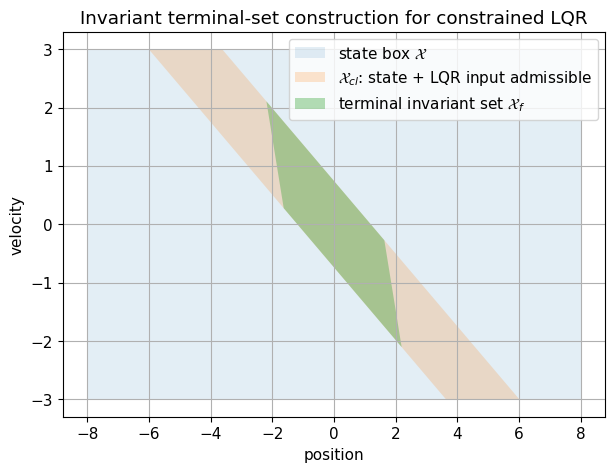

invariance iterations: 2
number of terminal-set vertices: 4


In [7]:
# Build a state/input admissible region for the local LQR controller.
x_lower = np.array([-8.0, -3.0])
x_upper = np.array([ 8.0,  3.0])
u_max = 1.0

X_box = HPolytope.box(x_lower, x_upper)
H_cl = np.vstack([X_box.H, K, -K])
h_cl = np.r_[X_box.h, u_max, u_max]
X_cl = HPolytope(H_cl, h_cl).remove_redundancy()

Xf, hist = maximal_invariant(Acl, X_cl, max_iter=100)
V_box = X_box.vertices_2d()
V_cl = X_cl.vertices_2d()
V_f = Xf.vertices_2d()

fig, ax = plt.subplots(figsize=(7, 5))
if len(V_box):
    ax.fill(V_box[:,0], V_box[:,1], alpha=0.12, label=r"state box $\mathcal{X}$")
if len(V_cl):
    ax.fill(V_cl[:,0], V_cl[:,1], alpha=0.20, label=r"$\mathcal{X}_{cl}$: state + LQR input admissible")
if len(V_f):
    ax.fill(V_f[:,0], V_f[:,1], alpha=0.35, label=r"terminal invariant set $\mathcal{X}_f$")
ax.set_xlabel("position")
ax.set_ylabel("velocity")
ax.set_title("Invariant terminal-set construction for constrained LQR")
ax.legend()
plt.show()

print("invariance iterations:", len(hist)-1)
print("number of terminal-set vertices:", len(V_f))


---
<a id="part-7"></a>
# Part VII — Why terminal ingredients matter in MPC

## VII.1 The standard terminal-set stability mechanism

Consider the MPC problem

$$
V_N^*(x)=
\min_U
\left[
\sum_{k=0}^{N-1}\ell(x_k,u_k)+V_f(x_N)
\right]
$$

with terminal constraint

$$
x_N\in\mathcal X_f.
$$

Assume there exists a local terminal controller $\kappa_f(x)$ such that for every $x\in\mathcal X_f$:

1. **invariance**

$$
f(x,\kappa_f(x))\in\mathcal X_f;
$$

2. **constraint admissibility**

$$
x\in\mathcal X,\qquad \kappa_f(x)\in\mathcal U;
$$

3. **terminal Lyapunov decrease**

$$
\boxed{
V_f(f(x,\kappa_f(x)))-V_f(x)
\le -\ell(x,\kappa_f(x)).
}
$$

These assumptions are the conceptual heart of stabilizing MPC.


## VII.2 Recursive feasibility: the shifted-sequence argument

Suppose at time $t$ an optimal feasible sequence is

$$
U_t^*=\{u_{0|t}^*,u_{1|t}^*,\ldots,u_{N-1|t}^*\},
$$

with predicted terminal state $x_{N|t}^*\in\mathcal X_f$.

MPC applies $u_{0|t}^*$. At the next time step, consider the **candidate** sequence

$$
\widetilde U_{t+1}
=
\{u_{1|t}^*,\ldots,u_{N-1|t}^*,\kappa_f(x_{N|t}^*)\}.
$$

Why is this candidate feasible in the nominal case?

- all shifted predicted states were already feasible;
- $x_{N|t}^*\in\mathcal X_f$;
- the terminal controller respects constraints;
- invariance guarantees the new final state remains in $\mathcal X_f$.

Therefore

$$
\boxed{\text{feasible at }t\Rightarrow\text{feasible at }t+1}
$$

under the theorem assumptions.

This is a proof of **recursive feasibility**, not merely a numerical observation.


## VII.3 Stability: the optimal MPC value as a Lyapunov function

The same shifted candidate provides a cost comparison. Since the optimizer at $t+1$ can only do better than a feasible candidate,

$$
V_N^*(x_{t+1})
\le
V_N^*(x_t)
-
\ell(x_t,u_t^*)
+
\underbrace{
V_f(x_{N+1})-V_f(x_N)
+
\ell(x_N,\kappa_f(x_N))
}_{\le0}.
$$

Hence

$$
\boxed{
V_N^*(x_{t+1})-V_N^*(x_t)
\le
-\ell(x_t,u_t^*).
}
$$

With a positive-definite stage cost, the optimal value decreases and acts as a Lyapunov function.

### Linear-quadratic terminal ingredients

For $u=-Kx$ and $V_f=x^\top Px$ from the DARE,

$$
V_f((A-BK)x)-V_f(x)
=-x^\top(Q+K^\top RK)x
=-\ell(x,-Kx).
$$

So the LQR pair $(K,P)$ naturally satisfies the required local decrease condition; the remaining task is to choose an invariant terminal set where the constraints are also satisfied.


> ### What this theorem does **not** say
>
> - It does not say every MPC formulation is stable.
> - It does not say a long horizon automatically proves stability.
> - It does not make nominal guarantees robust to disturbances/model error.
> - It does not remove the need to check feasibility of the initial condition.
>
> These distinctions become crucial in real autonomous systems.


---
<a id="part-8"></a>
# Part VIII — Dynamic programming and value functions

## VIII.1 Bellman's principle of optimality

For

$$
x_{k+1}=f(x_k,u_k)
$$

and finite-horizon cost

$$
J=
 g_N(x_N)+\sum_{k=0}^{N-1}g_k(x_k,u_k),
$$

define the optimal cost-to-go $J_k^*(x)$ from stage $k$ onward.

The terminal condition is

$$
J_N^*(x)=g_N(x),
$$

and backward recursion gives

$$
\boxed{
J_k^*(x)
=
\min_{u\in\mathcal U_k(x)}
\left[
 g_k(x,u)+J_{k+1}^*(f(x,u))
\right].
}
$$

This is Bellman's equation for deterministic finite-horizon optimal control.

### The deep connection to MPC

An ideal infinite-horizon value function contains the exact cost of the entire future. MPC cannot generally compute that online, so it truncates the horizon and inserts a **terminal cost** $V_f$ as an approximation of the missing tail.

That is why terminal costs are not arbitrary tuning terms: conceptually they approximate a value function.


### VIII.1.1 Control vocabulary versus RL vocabulary

The same mathematics often appears under different names.

| Control / DP language | RL language |
|---|---|
| system | environment |
| controller / decision maker | agent |
| control input | action |
| stage cost | negative reward |
| cost-to-go / value function | value function |
| state-action cost / Q-factor | Q-value |
| solve DP using a known model | planning |
| infer value/policy from interaction/data | learning |
| finite task repetition | episode |

The vocabulary changes, but Bellman's principle remains the organizing equation.

### Curse of dimensionality

Dynamic programming recursively solves low-dimensional decision problems, but the value function must be represented over the state space. A grid with $M$ points per dimension requires $M^n$ state samples in $n$ dimensions. This exponential growth motivates approximation, learning, and structured optimization methods.


---
<a id="part-9"></a>
# Part IX — From designed terminal ingredients to Learning MPC

## IX.1 Why learn a terminal set or terminal value?

Classical stabilizing MPC asks us to supply:

- a terminal set $\mathcal X_f$ that is invariant/admissible;
- a terminal cost $V_f$ with a suitable decrease property.

For constrained nonlinear systems these objects can be difficult to compute.

Learning MPC (LMPC) targets a special but important situation:

> **the same control task is repeated over iterations** — regulation runs, repeated path following, manufacturing cycles, racing laps, etc.

If an earlier iteration completed the task safely, every state visited on that successful trajectory comes with something extremely valuable:

1. a **known feasible continuation** to the goal;
2. an observed **cost-to-go** along that continuation.

LMPC turns these facts into terminal ingredients.


## IX.2 Sampled safe set

Let iteration $i$ generate a successful trajectory

$$
\mathbf x^i=\{x_0^i,x_1^i,\ldots,x_{T_i}^i\}
$$

with associated admissible inputs

$$
\mathbf u^i=\{u_0^i,\ldots,u_{T_i-1}^i\}.
$$

After iterations $0,\ldots,j$, a sampled safe set can be formed from all states on successful trajectories:

$$
\boxed{
\mathcal{SS}^j
=
\bigcup_{i=0}^{j}
\bigcup_{t=0}^{T_i}
\{x_t^i\}
\quad
(\text{possibly augmented by a terminal region }\mathcal O).
}
$$

Why “safe”? Because from each stored state we already know at least one admissible sequence that completed the task: the remainder of the historical trajectory.

For deterministic repeated tasks, this creates a data-driven certificate of **existence of a feasible continuation** for the sampled points.


## IX.3 Convex safe set and barycentric coordinates

For a linear system with convex state/input constraints, it is often useful to convexify the sampled states:

$$
\boxed{
\mathcal{CS}^j=\mathrm{conv}(\mathcal{SS}^j).
}
$$

A point $x\in\mathcal{CS}^j$ can be represented as

$$
x=\sum_{r=1}^{M}\lambda_r x_r,
$$

where

$$
\lambda_r\ge0,
\qquad
\sum_{r=1}^{M}\lambda_r=1.
$$

The $\lambda_r$ are barycentric coordinates.

Why does convexification help in the linear/convex setting? If each stored point $x_r$ has an admissible continuation/input, then convex combinations of states can be propagated by convex combinations of the corresponding inputs. Linearity and convex constraints preserve admissibility. Under the standard assumptions, this makes the convex safe set control invariant.


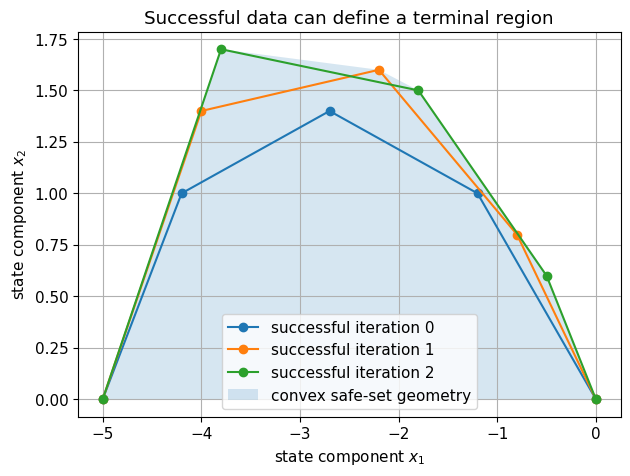

In [8]:
# Geometry only: visualize sampled safe states and their convex hull.
# The points mimic states collected from several successful iterations.
traj1 = np.array([[-5.0, 0.0], [-4.2, 1.0], [-2.7, 1.4], [-1.2, 1.0], [0.0, 0.0]])
traj2 = np.array([[-5.0, 0.0], [-4.0, 1.4], [-2.2, 1.6], [-0.8, 0.8], [0.0, 0.0]])
traj3 = np.array([[-5.0, 0.0], [-3.8, 1.7], [-1.8, 1.5], [-0.5, 0.6], [0.0, 0.0]])
pts = np.vstack([traj1, traj2, traj3])

hull = ConvexHull(pts)
Hpts = pts[hull.vertices]

fig, ax = plt.subplots(figsize=(7,5))
for i, tr in enumerate([traj1, traj2, traj3]):
    ax.plot(tr[:,0], tr[:,1], "o-", label=f"successful iteration {i}")
ax.fill(Hpts[:,0], Hpts[:,1], alpha=0.18, label="convex safe-set geometry")
ax.set_xlabel("state component $x_1$")
ax.set_ylabel("state component $x_2$")
ax.set_title("Successful data can define a terminal region")
ax.legend()
plt.show()


## IX.4 Learning a terminal value from stored cost-to-go

For a stored trajectory $i$, define the realized cost-to-go from time $t$:

$$
J_{t\rightarrow T_i}^{i}
=
\sum_{k=t}^{T_i-1}
\ell(x_k^i,u_k^i)
+
V_{\mathcal O}(x_{T_i}^i).
$$

If $x$ is represented as a convex combination of stored states,

$$
x=\sum_r\lambda_rx_r,
$$

one can construct a learned terminal value by solving a barycentric interpolation problem such as

$$
\boxed{
\widehat V^j(x)
=
\min_{\lambda}
\sum_r\lambda_r J_r
}
$$

subject to

$$
\sum_r\lambda_rx_r=x,
\qquad
\sum_r\lambda_r=1,
\qquad
\lambda_r\ge0.
$$

Then an LMPC can use

$$
x_N\in\mathcal{CS}^j,
\qquad
V_f(x_N)=\widehat V^j(x_N).
$$

So the classical pair

$$
\boxed{\mathcal X_f,\;V_f}
$$

is replaced/augmented by the data-driven pair

$$
\boxed{\mathcal{CS}^j,\;\widehat V^j}.
$$

> **LMPC is not synonymous with deep reinforcement learning.** In the formulation studied here, the “learning” can be entirely geometric and optimization-based: successful trajectories supply terminal feasibility and terminal performance information.


### IX.4.1 Classical MPC, LMPC, and RL — one conceptual map

| Question | Classical MPC | Learning MPC | RL / approximate DP |
|---|---|---|---|
| Is a model used online? | yes | yes (possibly learned/local) | may be model-free or model-based |
| Constraints explicit in online optimization? | yes | yes | not automatically |
| Terminal knowledge | designed $\mathcal X_f,V_f$ | learned from successful data | value/policy approximation |
| Main learning object | none necessarily | safe set / terminal value / possibly model | value, Q-function, policy, model |
| Repeated task useful? | not required | central | often episodic but not required |

This table is intentionally conceptual; many modern methods blur these categories.


---
<a id="part-10"></a>
# Part X — Preview: autonomous racing in Frenet coordinates

## X.1 Why change coordinates?

For path-following and racing, global Cartesian coordinates $(X,Y)$ are not always the most natural coordinates for optimization. If the track centerline is parameterized by arc length $s$, define Frenet-type errors

$$
(s,e_y,e_\psi),
$$

where

- $s$: progress along the path;
- $e_y$: lateral deviation from the centerline;
- $e_\psi$: heading error relative to the path tangent.

A track boundary becomes a simple constraint such as

$$
|e_y(s)|\le W(s).
$$

A minimum-time raceline problem then trades off:

- progress/lap time;
- track geometry and curvature $\kappa(s)$;
- vehicle dynamics;
- tire/input limits;
- track boundaries.

The later racing notebooks use this geometry to bridge optimal control, MPC, local model learning, and repeated-task learning.


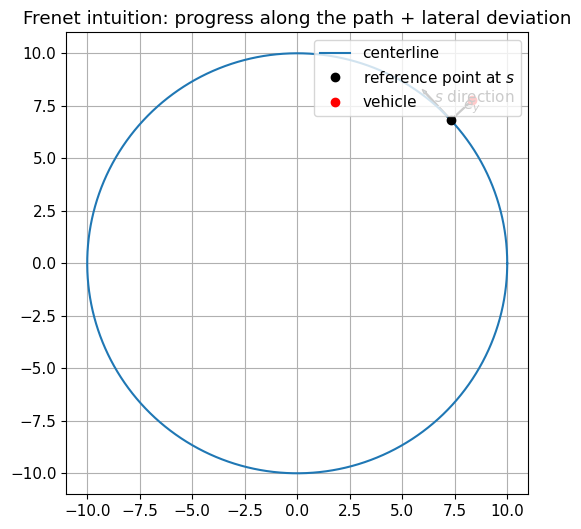

In [9]:
# A tiny geometric preview of Frenet coordinates on a circular centerline.
theta = np.linspace(0, 2*np.pi, 400)
Rtrack = 10.0
xc, yc = Rtrack*np.cos(theta), Rtrack*np.sin(theta)

th = 0.75
center = np.array([Rtrack*np.cos(th), Rtrack*np.sin(th)])
tangent = np.array([-np.sin(th), np.cos(th)])
normal = np.array([np.cos(th), np.sin(th)])
ey = 1.4
vehicle = center + ey*normal

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(xc, yc, label="centerline")
ax.plot(*center, "ko", label="reference point at $s$")
ax.plot(*vehicle, "ro", label="vehicle")
ax.arrow(*center, *(2.0*tangent), width=0.05, length_includes_head=True)
ax.arrow(*center, *(ey*normal), width=0.04, length_includes_head=True)
ax.text(*(center + 1.2*tangent), "$s$ direction")
ax.text(*(center + 0.55*ey*normal), "$e_y$")
ax.set_aspect("equal")
ax.set_title("Frenet intuition: progress along the path + lateral deviation")
ax.legend(loc="upper right")
plt.show()


---
<a id="part-11"></a>
# Part XI — Common conceptual pitfalls

## XI.1 Things worth catching before an implementation review

1. **Discrete stability is not $\Re\lambda<0$.** That is continuous time. Discrete time requires $|\lambda|<1$.
2. **With $u=-Kx$, the closed-loop matrix is $A-BK$.** A plus sign corresponds to a different feedback convention.
3. **A feasible MPC problem is not automatically stable.** Feasibility and stability are different properties.
4. **A long horizon is not a proof.** It can improve behavior, but a guarantee needs assumptions/analysis.
5. **A terminal cost is not just an extra weight.** It represents the unmodeled tail of the horizon and can support a Lyapunov proof.
6. **A terminal set is not merely a final box.** In stabilizing MPC it is usually designed to be admissible and invariant under a local controller.
7. **Nominal constraint satisfaction is not robust safety.** Disturbances/model error require additional design.
8. **Control invariance has an existential input quantifier.** $\forall x\in\mathcal C,\exists u$.
9. **LMPC learning does not require a neural network.** Safe sets and value functions can be learned directly from successful trajectories.
10. **Prediction model $\neq$ plant.** MPC performance and robustness depend on the gap between them.


---
<a id="part-12"></a>
# Part XII — Check your understanding

Try answering each question **before** opening the answer.

### Q1. Why is MPC a feedback controller if it solves an open-loop optimization?

<details><summary>Answer</summary>

At each sampling instant the optimization is re-solved using the new measured/estimated state. The applied law is $u(t)=u_{0|t}^*(x(t))$, so the first optimizer output depends on the current state and defines an implicit feedback map.

</details>

### Q2. What is the algebraic backbone of condensed linear MPC?

<details><summary>Answer</summary>

The stacked prediction identity $X=\mathcal S_xx_0+\mathcal S_uU$, which eliminates predicted states from the optimization and expresses them as an affine function of the initial state and future inputs.

</details>

### Q3. When is a linear MPC problem a convex QP?

<details><summary>Answer</summary>

With linear/affine dynamics, a convex quadratic objective ($Q,P\succeq0$, $R\succ0$) and affine/polyhedral constraints. Then the condensed Hessian is positive semidefinite (typically definite because of $R\succ0$) and constraints are linear.

</details>

### Q4. Difference between feasible and recursively feasible?

<details><summary>Answer</summary>

Feasible means an admissible sequence exists at the current state. Recursive feasibility means applying the controller keeps the next state inside the set of states from which the optimization remains feasible.

</details>

### Q5. What makes the standard terminal-set proof work?

<details><summary>Answer</summary>

A local terminal controller that keeps $\mathcal X_f$ invariant while satisfying constraints, plus a terminal cost whose decrease under that controller dominates the stage cost. The shifted optimal sequence plus one terminal control move is then feasible at the next step.

</details>

### Q6. Why does LQR naturally provide an MPC terminal cost?

<details><summary>Answer</summary>

The DARE solution gives $V_f=x^\top Px$ and $u=-Kx$ satisfying $V_f((A-BK)x)-V_f(x)=-x^\top(Q+K^\top RK)x=-\ell(x,-Kx)$.

</details>

### Q7. Why is a sampled LMPC state “safe” in the deterministic repeated-task setting?

<details><summary>Answer</summary>

Because it belongs to a previously successful admissible trajectory. The remainder of that stored trajectory is a known feasible continuation from that state to the task completion region.

</details>

### Q8. Why can convexification preserve safety/control invariance in the linear-convex LMPC setting?

<details><summary>Answer</summary>

Linearity maps convex combinations of states/inputs to convex combinations of next states, while convex constraints preserve admissibility. Thus barycentric combinations of known safe transitions remain admissible under the standard assumptions.

</details>

### Q9. How are Bellman value functions related to MPC terminal costs?

<details><summary>Answer</summary>

The exact infinite-horizon value function represents the optimal future tail cost. Finite-horizon MPC truncates the future and uses $V_f$ as an approximation/certificate for the omitted tail.

</details>

### Q10. What changes first when moving from textbook MPC to a real vehicle?

<details><summary>Answer</summary>

The assumptions: the state is estimated rather than perfectly known, the prediction model is imperfect, disturbances exist, constraints may be uncertain, actuators have dynamics/delays, and computation is finite. These motivate observers, robust/stochastic MPC, model adaptation, safety monitors, and real-time implementation analysis.

</details>


---
<a id="part-13"></a>
# Part XIII — Exercises

### Exercise 1 — Derive the prediction matrices by hand

For

$$
A=\begin{bmatrix}1&1\\0&1\end{bmatrix},\qquad
B=\begin{bmatrix}0.5\\1\end{bmatrix},
$$

write $x_1,x_2,x_3$ explicitly and construct $\mathcal S_x,\mathcal S_u$ for $N=3$. Verify numerically against `prediction_matrices`.

### Exercise 2 — Condense a state constraint

Suppose $|p_k|\le 6$ for every predicted state. Write this as $H_xx_k\le h_x$, stack it over the horizon, and derive the inequality in $U$.

### Exercise 3 — Stability convention

Take an arbitrary feedback row $K=[k_1\;k_2]$. Compute the eigenvalues of both $A-BK$ and $A+BK$. Explain why only one corresponds to the convention $u=-Kx$.

### Exercise 4 — Terminal decrease

Using the numerical LQR matrices computed above, draw 100 random states $x$ and verify

$$
V((A-BK)x)-V(x)=-x^\top(Q+K^\top RK)x
$$

up to numerical precision.

### Exercise 5 — Safe-set reasoning

Pick one state on `traj2`. Explain the exact known feasible continuation. Then pick a point strictly inside the plotted convex hull that was never sampled. Explain why claiming it is safe requires the linearity/convexity assumptions; historical data alone is not enough for arbitrary nonlinear dynamics.

### Exercise 6 — Think like a controls engineer

For each of the following, decide whether the statement concerns **feasibility**, **stability**, **invariance**, **optimality**, or **robustness**:

1. “The QP has a solution at every closed-loop time step.”
2. “The state converges to the origin.”
3. “Once inside this set, the local controller never leaves it.”
4. “No other admissible horizon trajectory has a smaller finite-horizon cost.”
5. “Constraints remain satisfied for all disturbances in a prescribed set.”


---
<a id="part-14"></a>
# Part XIV — Notation cheat sheet

| Symbol | Meaning |
|---|---|
| $x_k\in\mathbb R^n$ | state |
| $u_k\in\mathbb R^m$ | control input |
| $A,B$ | LTI state/input matrices |
| $N$ | prediction horizon |
| $X,U$ | stacked future states/inputs |
| $\mathcal S_x,\mathcal S_u$ | stacked prediction matrices |
| $\mathcal X,\mathcal U$ | admissible state/input sets |
| $\mathcal X_f$ | terminal set |
| $\ell(x,u)$ | stage cost |
| $V_f(x)$ | terminal cost |
| $V_N^*(x)$ | optimal finite-horizon MPC value |
| $K$ | LQR gain under $u=-Kx$ |
| $P$ | DARE / quadratic value-function matrix |
| $\rho(A)$ | spectral radius |
| $\mathrm{Pre}(\mathcal S)$ | one-step predecessor of set $\mathcal S$ |
| $\mathcal{SS}^j$ | sampled safe set after LMPC iteration $j$ |
| $\mathcal{CS}^j$ | convex safe set |
| $\lambda_r$ | barycentric coordinates |
| $J_k^*(x)$ | Bellman optimal cost-to-go |
| $(s,e_y,e_\psi)$ | Frenet progress, lateral error, heading error |


---
<a id="part-15"></a>
# Part XV — Scope and references

**Scope.** This notebook is a map of the whole series. It introduces the shared notation and, at the level needed to follow the later notebooks, the main ideas: discrete-time models and multi-step prediction, the QP form of linear-quadratic finite-horizon control, the receding-horizon principle, Lyapunov stability and LQR, predecessor and invariant sets, the terminal-set mechanism behind stabilizing MPC, Bellman's recursion, Learning MPC, and Frenet coordinates for racing. It assumes linear algebra, basic calculus and familiarity with state-space models. The derivations sketched here are developed in full, with numerical examples, in Notebooks 01–09.

**References.**

- S. Boyd and L. Vandenberghe, *Convex Optimization*, Cambridge University Press, 2004: convexity, quadratic programs, duality.
- F. Borrelli, A. Bemporad and M. Morari, *Predictive Control for Linear and Hybrid Systems*, Cambridge University Press, 2017: constrained finite-time optimal control, invariant sets, MPC feasibility and stability.
- J. B. Rawlings, D. Q. Mayne and M. M. Diehl, *Model Predictive Control: Theory, Computation, and Design*, 2nd ed., Nob Hill Publishing, 2022: MPC theory and computation.
- D. Q. Mayne, J. B. Rawlings, C. V. Rao and P. O. M. Scokaert, "Constrained model predictive control: Stability and optimality", *Automatica*, 36(6), 789–814, 2000: terminal ingredients and stability.
- F. Blanchini and S. Miani, *Set-Theoretic Methods in Control*, 2nd ed., Birkhäuser, 2015: invariant and controllable sets.
- H. K. Khalil, *Nonlinear Systems*, 3rd ed., Prentice Hall, 2002: Lyapunov stability.
- D. P. Bertsekas, *Dynamic Programming and Optimal Control*, Vol. I, 4th ed., Athena Scientific, 2017: Bellman's recursion.
- R. S. Sutton and A. G. Barto, *Reinforcement Learning: An Introduction*, 2nd ed., MIT Press, 2018: the reinforcement-learning view of value functions.
- U. Rosolia and F. Borrelli, "Learning Model Predictive Control for Iterative Tasks. A Data-Driven Control Framework", *IEEE Transactions on Automatic Control*, 63(7), 1883–1896, 2018: sampled safe sets and learned terminal costs.
- G. Perantoni and D. J. N. Limebeer, "Optimal control for a Formula One car with variable parameters", *Vehicle System Dynamics*, 52(5), 2014: minimum-time control in curvilinear (Frenet) coordinates.

For implementation details and reproducible examples, the later notebooks are the primary reference inside this repository.

---

## Next notebook

Continue with **[01 — Convex Optimization and CFTOC](01_convex_optimization_and_cftoc.ipynb)**.

A useful target before moving on: you should be able to derive $X=\mathcal S_xx_0+\mathcal S_uU$, explain the shifted-sequence feasibility proof, and state why $P$ from the DARE is a natural terminal value matrix.
